# Exploratory analysis of the fault-diagnosis feature set

Before trusting a classifier that scores 1.0 on held-out seeds, look at the data it was fitted on.
This notebook reads the three feature tables that `scripts/ml_baseline.py features` writes into
`runs_ml/ml/` for the 10-seed, 360-run matrix and asks the questions an EDA should answer before
any model is trained:

1. **Inventory**: what is in the dataset, and is the matrix complete
2. **Class balance**: how many windows per class, and where the labels come from
3. **Augmentation**: do onsets and targets really move with the seed
4. **Missing values**: which features are undefined, and when
5. **Scale**: are the features mesh-invariant, as claimed, and which ones are not
6. **Separability**: which single feature identifies each class
7. **Redundancy**: how correlated the features are
8. **Structure**: what a two-dimensional projection shows
9. **The hard pairs**: healthy vs phase change, and full vs subset allocation
10. **Entity tables**: what the per-GPU and per-rack positives look like

Nothing is fitted here except a PCA for plotting. Every number comes from the cached parquet files,
so the notebook runs in a couple of minutes. Companion material: `ml_fault_diagnosis.ipynb`
(the training walk-through) and `ML_FAULT_DIAGNOSIS.pdf`.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

ROOT = Path.cwd().resolve()
while not (ROOT / "scripts" / "ml_baseline.py").exists():
    assert ROOT.parent != ROOT, "run this notebook from inside the repository"
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
import ml_baseline as mb

RUNS = ROOT / "runs_ml"
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 3)
A, B, C, G, INK3 = "#c2410c", "#0f766e", "#1e40af", "#15803d", "#8a807a"
PAL = {"healthy": INK3, "straggler": A, "network_domain": C, "thermal": "#b45309",
       "gpu_degradation": "#7c3aed", "phase_change": G}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": False, "font.size": 9})

win = pd.read_parquet(RUNS / "ml" / "features_window.parquet")
gpu = pd.read_parquet(RUNS / "ml" / "features_gpu.parquet")
rack = pd.read_parquet(RUNS / "ml" / "features_rack.parquet")
manifest = json.loads((RUNS / "manifest.json").read_text())
labelled = win[win["train_stride"] & (win["label"] != "straddle")].reset_index(drop=True)
cols = mb._cols(labelled)
print(f"window table {win.shape}, gpu table {gpu.shape}, rack table {rack.shape}")
print(f"{win['run_id'].nunique()} runs; {len(win):,} stride-10 windows; {len(labelled):,} labelled training windows; {len(cols)} model features")

window table (32760, 67), gpu table (568480, 34), rack table (22276, 28)
360 runs; 32,760 stride-10 windows; 6,366 labelled training windows; 50 model features


## 1. Inventory

The matrix is 6 scenarios × 3 meshes × 10 seeds, each simulated on the full cluster and once more
under a seed-drawn subset allocation. Every cell should be present exactly once, and every run
should yield the same number of windows because windows are defined in iterations, not seconds.

In [2]:
runs = win.drop_duplicates("run_id")[["run_id", "scenario", "mesh", "seed", "alloc", "n_ranks", "placement"]]
print("seeds:", sorted(runs["seed"].unique()))
print("runs per (scenario, mesh), all seeds and both allocation twins:")
display(runs.pivot_table(index="scenario", columns="mesh", values="run_id", aggfunc="count").loc[mb.CLASSES])
print("runs by allocation profile and rank count:")
display(runs.groupby(["alloc", "n_ranks", "placement"])["run_id"].count().rename("runs").reset_index())
wpr = win.groupby("run_id").size()
print(f"windows per run: min {wpr.min()}, max {wpr.max()} (identical across meshes, as intended)")

seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
runs per (scenario, mesh), all seeds and both allocation twins:


mesh,coarse,fine,medium
scenario,,,
healthy,20,20,20
straggler,20,20,20
network_domain,20,20,20
thermal,20,20,20
gpu_degradation,20,20,20
phase_change,20,20,20


runs by allocation profile and rank count:


,alloc,n_ranks,placement,runs
0,full,128,packed,180
1,nodes8_packed,64,packed,42
2,rack1_packed,32,packed,36
3,racks2_packed,64,packed,34
4,scatter32,32,scatter,39
5,scatter64,64,scatter,29


windows per run: min 91, max 91 (identical across meshes, as intended)


## 2. Class balance and where the labels come from

Labels are not the scenario name. A window is `healthy` until the injector's own `INJECTION_APPLIED`
event fires, so every faulted run contributes healthy windows before its onset; windows that straddle
the onset are dropped from training. Straggler runs are labelled per window from the episode schedule,
so a straggler run alternates between the two classes. That is why `healthy` dominates and why a
model that always says healthy would already score well on accuracy: the deck reports macro-F1.

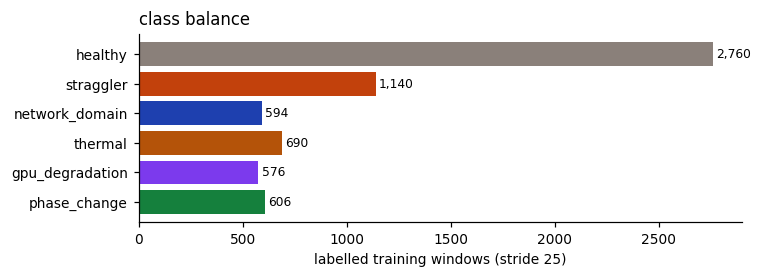

share of healthy windows: 43.4%
labelled windows by allocation profile:


label,healthy,straggler,network_domain,thermal,gpu_degradation,phase_change
alloc,,,,,,
full,1380,570,297,345,288,303
nodes8_packed,301,133,37,92,60,118
rack1_packed,303,76,92,35,57,71
racks2_packed,212,114,55,67,91,53
scatter32,321,152,43,89,51,43
scatter64,243,95,70,62,29,18


In [3]:
counts = labelled["label"].value_counts().reindex(mb.CLASSES)
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(counts.index, counts.values, color=[PAL[c] for c in counts.index]); ax.invert_yaxis()
for i, v in enumerate(counts.values): ax.text(v + 15, i, f"{v:,}", va="center", fontsize=8)
ax.set_xlabel("labelled training windows (stride 25)"); ax.set_title("class balance", loc="left")
plt.tight_layout(); plt.show()
print("share of healthy windows: %.1f%%" % (100 * counts["healthy"] / counts.sum()))
print("labelled windows by allocation profile:")
labelled.pivot_table(index="alloc", columns="label", values="run_id", aggfunc="count", fill_value=0)[mb.CLASSES]

stride-10 windows by scenario (rows) and label (columns): faulted runs carry healthy and straddle windows too


label,healthy,straggler,network_domain,thermal,gpu_degradation,phase_change,straddle
scenario,,,,,,,
healthy,5460,0,0,0,0,0,0
straggler,0,5460,0,0,0,0,0
network_domain,2022,0,2850,0,0,0,588
thermal,1482,0,0,3378,0,0,600
gpu_degradation,2106,0,0,0,2754,0,600
phase_change,1962,0,0,0,0,2904,594


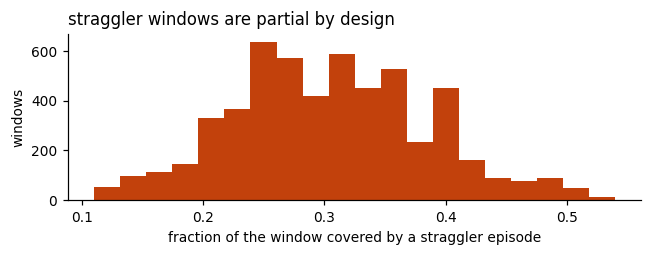

In [4]:
by_sc = win.groupby(["scenario", "label"]).size().unstack(fill_value=0)
print("stride-10 windows by scenario (rows) and label (columns): faulted runs carry healthy and straddle windows too")
display(by_sc.reindex(mb.CLASSES)[[c for c in mb.CLASSES if c in by_sc.columns] + ["straddle"]])
strag = win[(win["scenario"] == "straggler") & (win["fault_frac"] > 0)]
fig, ax = plt.subplots(figsize=(6, 2.4))
ax.hist(strag["fault_frac"], bins=20, color=A); ax.set_xlabel("fraction of the window covered by a straggler episode")
ax.set_ylabel("windows"); ax.set_title("straggler windows are partial by design", loc="left")
plt.tight_layout(); plt.show()

## 3. Onsets and targets move with the seed

Seeds are the augmentation axis. If the onset were fixed at the yaml value, iteration number would be
a perfect label proxy; if the target were fixed, entity identity would be. The manifest records what
the injector actually did for every run.

In [5]:
mf = pd.DataFrame([{"key": k, "scenario": v["scenario"], "mesh": v["mesh"], "seed": v["seed"],
                    "onset": v.get("at_iteration"), "target": json.dumps(v.get("target"), sort_keys=True),
                    "subset": "/" in k} for k, v in manifest.items()])
full = mf[~mf["subset"] & (mf["mesh"] == "medium")]
print("onset iteration by seed (medium mesh, full cluster); straggler has a per-seed episode schedule instead of one onset")
display(full.pivot_table(index="seed", columns="scenario", values="onset").reindex(columns=["thermal", "network_domain", "gpu_degradation", "phase_change"]).astype(int))
print("injected target by seed")
full.pivot_table(index="seed", columns="scenario", values="target", aggfunc="first")[["thermal", "network_domain", "gpu_degradation"]]

onset iteration by seed (medium mesh, full cluster); straggler has a per-seed episode schedule instead of one onset


scenario,thermal,network_domain,gpu_degradation,phase_change
seed,,,,
1,304,310,384,203
2,407,549,365,562
3,397,491,433,451
4,285,440,367,305
5,323,318,585,486
6,254,457,529,545
7,368,469,445,295
8,254,298,458,318
9,404,471,600,484


injected target by seed


scenario,thermal,network_domain,gpu_degradation
seed,,,
1,"{""rack"": 2}","{""rack"": 1}","{""gpu"": 2, ""node"": 3, ""rack"": 3}"
2,"{""rack"": 1}","{""rack"": 3}","{""gpu"": 1, ""node"": 3, ""rack"": 1}"
3,"{""rack"": 1}","{""rack"": 2}","{""gpu"": 6, ""node"": 3, ""rack"": 0}"
4,"{""rack"": 1}","{""rack"": 0}","{""gpu"": 5, ""node"": 3, ""rack"": 1}"
5,"{""rack"": 0}","{""rack"": 3}","{""gpu"": 3, ""node"": 1, ""rack"": 0}"
6,"{""rack"": 0}","{""rack"": 0}","{""gpu"": 7, ""node"": 3, ""rack"": 1}"
7,"{""rack"": 3}","{""rack"": 1}","{""gpu"": 4, ""node"": 3, ""rack"": 0}"
8,"{""rack"": 2}","{""rack"": 1}","{""gpu"": 1, ""node"": 1, ""rack"": 0}"
9,"{""rack"": 3}","{""rack"": 0}","{""gpu"": 5, ""node"": 0, ""rack"": 1}"


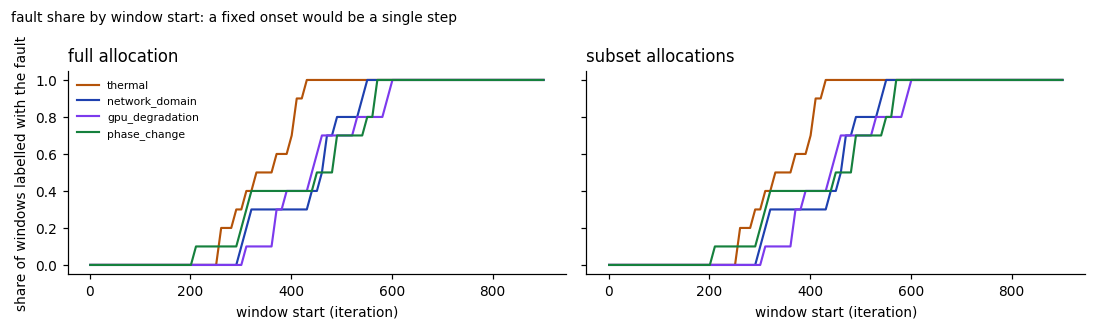

The ramps are gradual because onsets differ by seed: no single iteration separates healthy from faulted.
Straggler is omitted: its episode schedule covers every window, so every straggler-run window carries that label.


In [6]:
# is iteration position a label proxy? plot the share of fault-labelled windows against window start
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, alloc in zip(axes, ["full", "subset"]):
    d = win[(win["alloc"] == "full") if alloc == "full" else (win["alloc"] != "full")]
    for sc in ["thermal", "network_domain", "gpu_degradation", "phase_change"]:
        g = d[d["scenario"] == sc].groupby("start")["label"].apply(lambda s: (s == sc).mean())
        ax.plot(g.index, g.values, color=PAL[sc], label=sc, lw=1.4)
    ax.set_title(f"{alloc} allocation" + ("s" if alloc == "subset" else ""), loc="left")
    ax.set_xlabel("window start (iteration)")
axes[0].set_ylabel("share of windows labelled with the fault"); axes[0].legend(fontsize=7, frameon=False)
fig.suptitle("fault share by window start: a fixed onset would be a single step", x=0.01, ha="left", fontsize=9)
plt.tight_layout(); plt.show()
print("The ramps are gradual because onsets differ by seed: no single iteration separates healthy from faulted.")
print("Straggler is omitted: its episode schedule covers every window, so every straggler-run window carries that label.")

## 4. Missing values

A feature is `NaN` when its source has nothing to say: the fabric aggregation counters when the job
never crosses a rack, per-rack temperature drift when the job occupies one rack, storage latency when
no checkpoint fell inside the window. The trees handle `NaN` natively; the linear baseline imputes the
median. Missingness that depends on the allocation is itself information, so it is worth knowing
which features carry it.

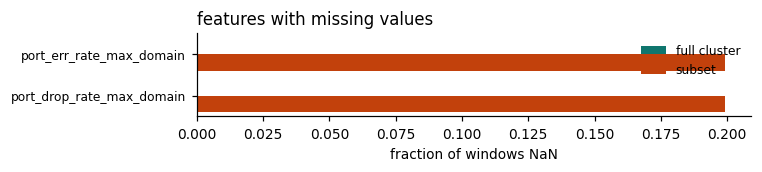

alloc,full,subset
port_err_rate_max_domain,0.0,0.199
port_drop_rate_max_domain,0.0,0.199


In [7]:
miss = labelled.groupby(labelled["alloc"].eq("full").map({True: "full", False: "subset"}))[cols].apply(lambda d: d.isna().mean()).T
miss = miss[(miss > 0).any(axis=1)].sort_values("subset", ascending=False)
if miss.empty:
    print("no missing values in any model feature")
else:
    fig, ax = plt.subplots(figsize=(7, 0.32 * len(miss) + 1))
    y = np.arange(len(miss))
    ax.barh(y - 0.2, miss["full"], 0.4, color=B, label="full cluster"); ax.barh(y + 0.2, miss["subset"], 0.4, color=A, label="subset")
    ax.set_yticks(y); ax.set_yticklabels(miss.index, fontsize=8); ax.invert_yaxis(); ax.set_xlabel("fraction of windows NaN")
    ax.legend(frameon=False, fontsize=8); ax.set_title("features with missing values", loc="left")
    plt.tight_layout(); plt.show()
    display(miss.round(3))

## 5. Are the features mesh-invariant?

The design claim is that every model feature is dimensionless, so the same model covers meshes whose
iteration times differ 20×. Dimensionless is necessary but not sufficient: a ratio can still take a
different *value* on each mesh if the physics differs. The two `abs_` columns and `job_ckpt_rel` are kept
in the table only for this check and are excluded from `mb._cols`. For each feature, on healthy windows
only, compute how well it identifies the mesh (one-vs-rest AUROC, best mesh). A perfectly invariant
feature scores 0.5; a mesh identifier scores 1.0.

In [8]:
healthy = labelled[labelled["label"] == "healthy"]
all_cols = mb._cols(labelled, absolute=True) + sorted(mb.WALLTIME_RATIOS & set(labelled.columns))
def mesh_auc(col):
    x = healthy[col].fillna(healthy[col].median())
    if x.nunique() < 2: return np.nan
    return max(max(a, 1 - a) for a in (roc_auc_score(healthy["mesh"] == m, x) for m in mb.MESHES))
mesh_id = pd.Series({c: mesh_auc(c) for c in all_cols})
excluded = [c for c in all_cols if c not in cols]
print("excluded columns:", {c: round(mesh_id[c], 3) for c in excluded})
mid = mesh_id[cols].dropna().sort_values(ascending=False)   # model features only, most mesh-bound first
print("most mesh-identifying MODEL features on healthy windows (0.5 = invariant, 1.0 = identifies the mesh):")
display(mid.head(12).round(3).rename("AUROC vs mesh").to_frame().T)
print("least mesh-identifying model features:")
display(mid.tail(8).round(3).rename("AUROC vs mesh").to_frame().T)
n_id = int((mid > 0.95).sum())
print(f"model features: median {mid.median():.3f}; {n_id} of {len(cols)} identify the mesh with AUROC > 0.95")
print("(job_output_duty is constant on healthy windows and is left out of the ranking)")

excluded columns: {'abs_iter_time_s': 1.0, 'abs_compute_mean_s': 1.0, 'job_ckpt_rel': 1.0}
most mesh-identifying MODEL features on healthy windows (0.5 = invariant, 1.0 = identifies the mesh):


,rank_halo_disp,gpu_util_occ_gap,job_halo_max_rel,gpu_occ_mean,job_iter_cv,gpu_power_cv,storage_dirty_backlog_mean,node_mem_pressure_mean,storage_active_frac,node_io_pressure_max,storage_write_lat_max,job_halo_over_compute
AUROC vs mesh,1.0,1.0,1.0,1.0,1.0,0.986,0.983,0.983,0.981,0.978,0.974,0.947


least mesh-identifying model features:


,nic_err_rate,agg_uplink_util_max,port_util_max,job_iter_slope_rel,rank_pace_top3,rank_pace_entropy,rank_pace_top1,port_err_rate_max_domain
AUROC vs mesh,0.627,0.624,0.624,0.617,0.61,0.594,0.577,0.531


model features: median 0.776; 11 of 50 identify the mesh with AUROC > 0.95
(job_output_duty is constant on healthy windows and is left out of the ranking)


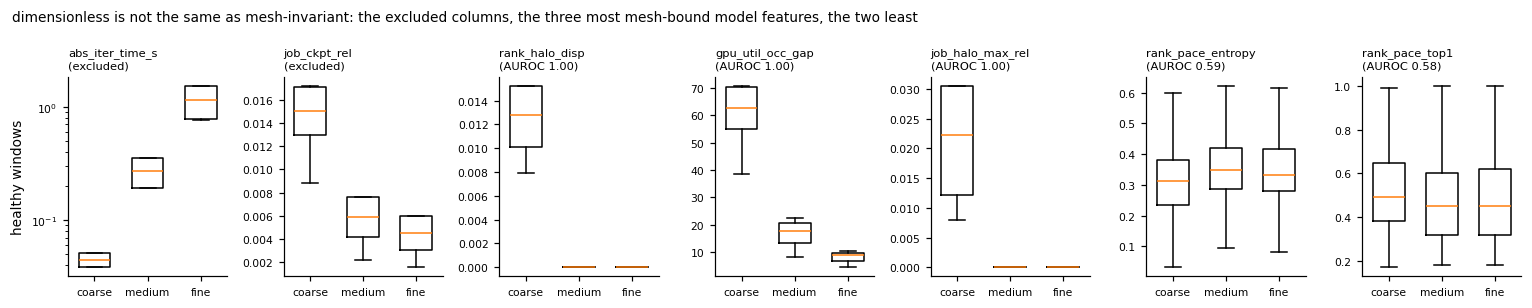

Halo-to-compute ratio and occupancy genuinely differ by mesh (surface-to-volume of the subdomain), so a model that
learns 'healthy looks like X' per mesh has nothing to anchor on for an unseen mesh. That is the mesh hold-out gap in the deck.


In [9]:
varying = [c for c in mid.index                                     # skip features that are near-constant when healthy
           if healthy[c].std() > 1e-6 and healthy[c].std() > 0.05 * abs(healthy[c].mean())]
show = ["abs_iter_time_s", "job_ckpt_rel"] + list(mid.index[:3]) + varying[-2:]
fig, axes = plt.subplots(1, len(show), figsize=(14, 2.8))
for ax, c in zip(axes, show):
    data = [healthy.loc[healthy["mesh"] == m, c].dropna() for m in mb.MESHES]
    ax.boxplot(data, tick_labels=mb.MESHES, showfliers=False, widths=0.6)
    tag = "excluded" if c not in cols else f"AUROC {mesh_id[c]:.2f}"
    ax.set_title(f"{c}\n({tag})", fontsize=7.5, loc="left"); ax.tick_params(labelsize=7)
    if c.startswith("abs_"): ax.set_yscale("log")
axes[0].set_ylabel("healthy windows")
fig.suptitle("dimensionless is not the same as mesh-invariant: the excluded columns, the three most mesh-bound model features, the two least",
             x=0.01, ha="left", fontsize=9)
plt.tight_layout(); plt.show()
print("Halo-to-compute ratio and occupancy genuinely differ by mesh (surface-to-volume of the subdomain), so a model that")
print("learns 'healthy looks like X' per mesh has nothing to anchor on for an unseen mesh. That is the mesh hold-out gap in the deck.")

## 6. Which single feature identifies each class?

One-vs-rest AUROC of every feature for every class, on the labelled windows. This is not a model:
it is the strongest univariate signal, and it says which telemetry table each fault lives in. Values
near 1.0 mean a single threshold would already find that class.

,best feature,AUROC,runner-up,AUROC (2nd)
healthy,job_sync_rel,0.831,job_spread_rel,0.814
straggler,rank_wait_min_rel,0.993,job_sync_rel,0.883
network_domain,port_down_frac,1.000,port_down_max_domain,1.000
thermal,gpu_rack_temp_drift,0.952,gpu_temp_max_minus_med,0.946
gpu_degradation,gpu_throttle_reliab_frac,1.000,rank_excess_max_mean,1.000
phase_change,job_output_duty,1.000,node_cpu_pressure_mean,1.000


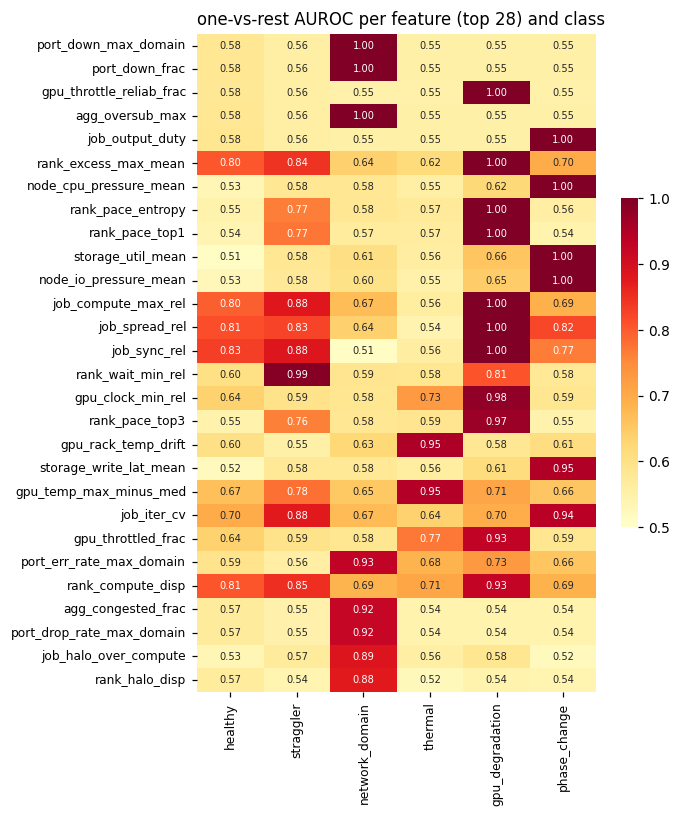

In [10]:
X = labelled[cols].fillna(labelled[cols].median())
sep = pd.DataFrame({c: {f: (lambda a: max(a, 1 - a))(roc_auc_score(labelled["label"] == c, X[f])) if X[f].nunique() > 1 else 0.5
                        for f in cols} for c in mb.CLASSES})
best = pd.DataFrame({"best feature": sep.idxmax(), "AUROC": sep.max().round(3),
                     "runner-up": sep.apply(lambda s: s.drop(s.idxmax()).idxmax()),
                     "AUROC (2nd)": sep.apply(lambda s: s.drop(s.idxmax()).max()).round(3)})
display(best)
top = sep.max(axis=1).sort_values(ascending=False).head(28).index
fig, ax = plt.subplots(figsize=(6.5, 7.5))
sns.heatmap(sep.loc[top], vmin=0.5, vmax=1, cmap="YlOrRd", annot=True, fmt=".2f", annot_kws={"size": 6.5}, cbar_kws={"shrink": 0.5}, ax=ax)
ax.set_title("one-vs-rest AUROC per feature (top 28) and class", loc="left"); ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

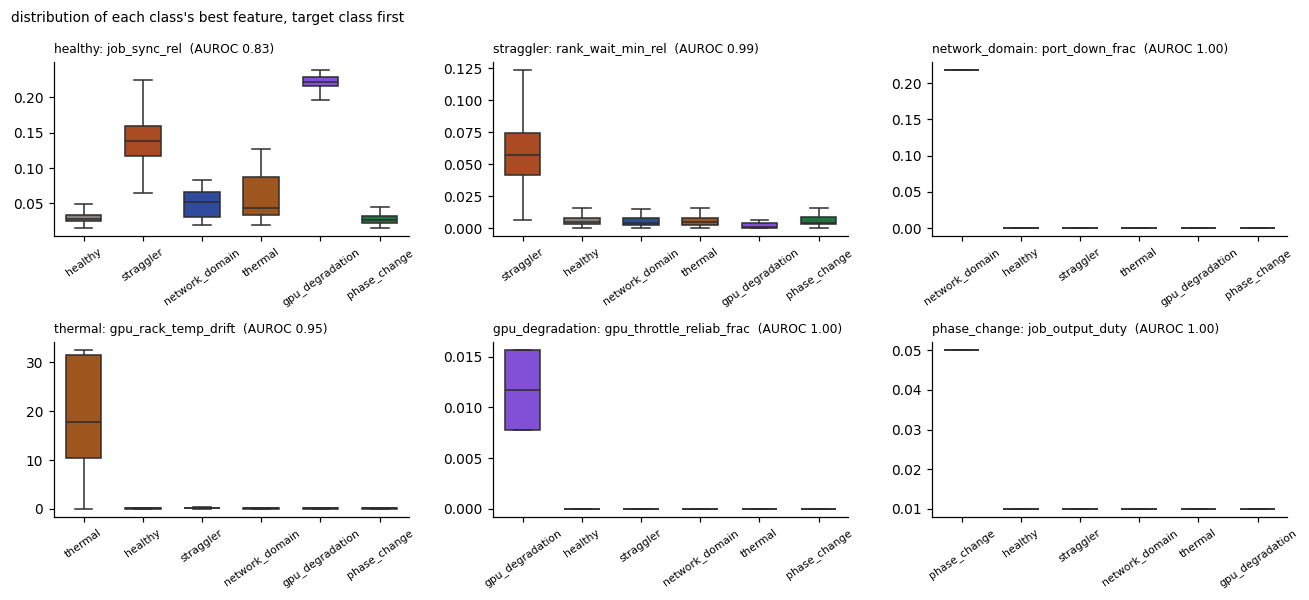

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(12, 5.5))
for ax, c in zip(axes.ravel(), mb.CLASSES):
    f = best.loc[c, "best feature"]
    order = [c] + [k for k in mb.CLASSES if k != c]
    sns.boxplot(data=labelled, x="label", y=f, order=order, palette=[PAL[k] for k in order], showfliers=False, width=0.6, ax=ax)
    ax.set_title(f"{c}: {f}  (AUROC {best.loc[c, 'AUROC']:.2f})", loc="left", fontsize=8)
    ax.set_xlabel(""); ax.set_ylabel(""); ax.tick_params(axis="x", labelrotation=35, labelsize=7)
fig.suptitle("distribution of each class's best feature, target class first", x=0.01, ha="left", fontsize=9)
plt.tight_layout(); plt.show()

## 7. Redundancy

Many features are near-duplicates by construction (a mean and a max of the same counter, a rate and
its p99). Spearman correlation on the labelled windows, clustered so the families show up as blocks.
Redundancy does not hurt the trees, but it inflates permutation importance's uncertainty: shuffling
one of a correlated pair costs little because its twin stands in for it.

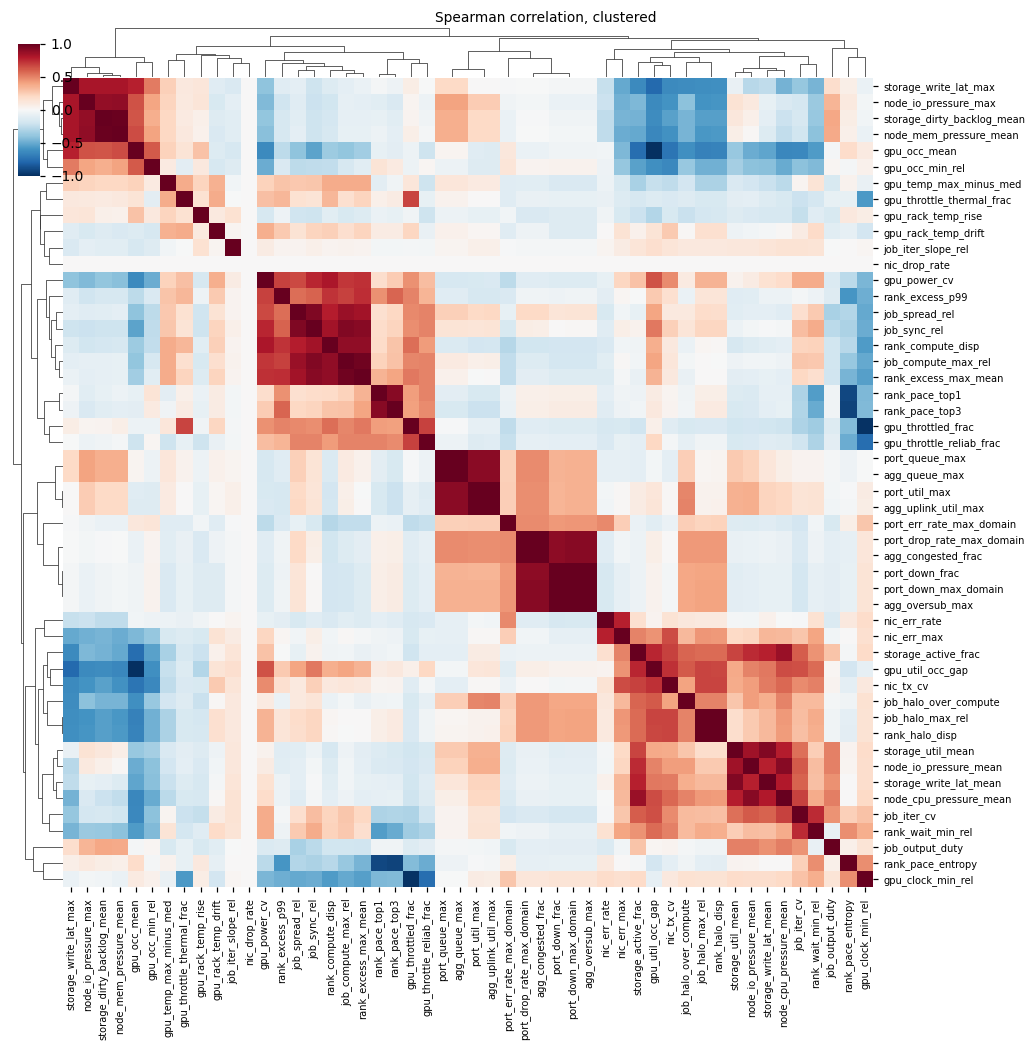

27 feature pairs with |rho| > 0.9:


,feature,feature,rho
0,port_down_max_domain,agg_oversub_max,1.000
1,port_queue_max,agg_queue_max,1.000
2,gpu_occ_mean,gpu_util_occ_gap,-1.000
3,port_drop_rate_max_domain,agg_congested_frac,1.000
4,port_down_frac,agg_oversub_max,0.999
5,port_down_frac,port_down_max_domain,0.999
6,job_halo_max_rel,rank_halo_disp,0.999
7,port_util_max,agg_uplink_util_max,0.999
8,gpu_clock_min_rel,gpu_throttled_frac,-0.989
9,storage_dirty_backlog_mean,node_mem_pressure_mean,0.985


In [12]:
corr = X.corr(method="spearman").fillna(0)
cg = sns.clustermap(corr, cmap="RdBu_r", vmin=-1, vmax=1, figsize=(10, 10), xticklabels=True, yticklabels=True,
                    dendrogram_ratio=0.06, cbar_pos=(0.02, 0.85, 0.02, 0.12))
cg.ax_heatmap.tick_params(labelsize=6.5); cg.fig.suptitle("Spearman correlation, clustered", x=0.5, y=1.0, fontsize=9)
plt.show()
pairs = corr.where(np.triu(np.ones_like(corr, dtype=bool), 1)).stack()
strong = pairs[pairs.abs() > 0.9].sort_values(key=abs, ascending=False)
print(f"{len(strong)} feature pairs with |rho| > 0.9:")
strong.round(3).rename("rho").reset_index().rename(columns={"level_0": "feature", "level_1": "feature "}).head(20)

## 8. A two-dimensional view

PCA on the standardised model features, coloured three ways. The class colouring shows whether the
faults form separate regions before any supervised fitting; the mesh and allocation colourings show
whether workload or cluster occupancy dominates the variance instead. If mesh were the first axis, the
mesh-invariance claim of section 5 would be hollow.

explained variance: [0.24  0.181]


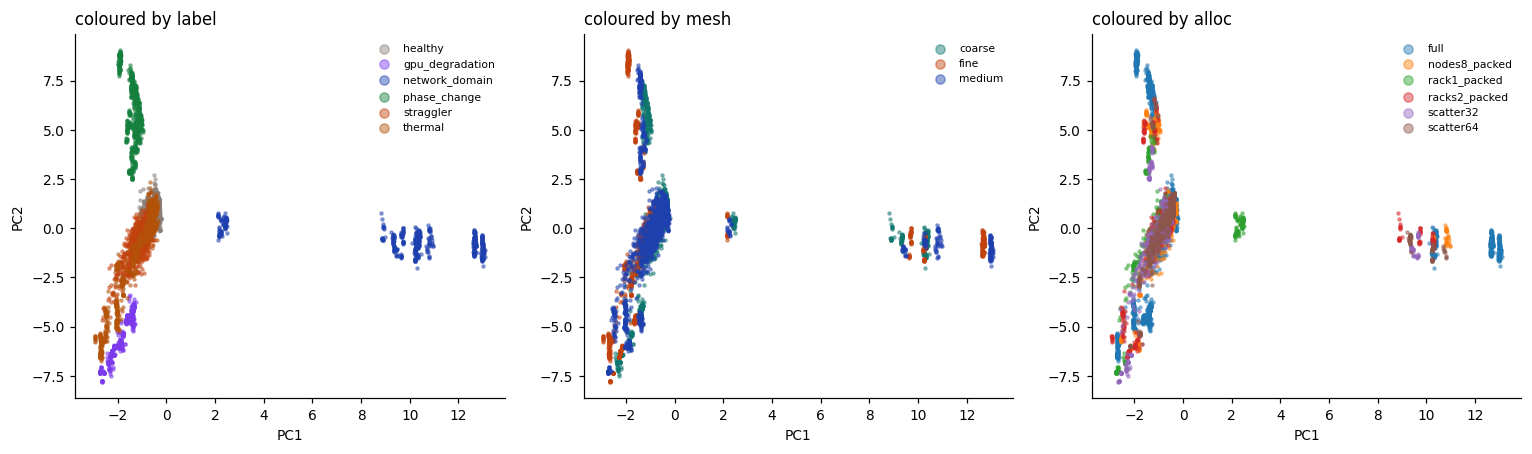

largest loadings:


,PC1,PC2
port_drop_rate_max_domain,0.29,NaN
port_err_rate_max_domain,0.29,NaN
port_util_max,0.28,NaN
agg_uplink_util_max,0.28,NaN
port_down_max_domain,0.28,NaN
agg_oversub_max,0.28,NaN
rank_compute_disp,NaN,0.25
gpu_clock_min_rel,NaN,0.25
rank_excess_max_mean,NaN,0.25
node_cpu_pressure_mean,NaN,0.25


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
Z = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=0).fit(Z); P = pca.transform(Z)
print("explained variance:", np.round(pca.explained_variance_ratio_, 3))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, key, pal in zip(axes, ["label", "mesh", "alloc"], [PAL, dict(zip(mb.MESHES, [B, C, A])), None]):
    keys = list(pd.unique(labelled[key]))
    if pal is None: pal = dict(zip(keys, plt.cm.tab10.colors))
    for k in keys:
        m = (labelled[key] == k).to_numpy()
        ax.scatter(P[m, 0], P[m, 1], s=4, alpha=0.45, color=pal[k], label=k, rasterized=True)
    ax.legend(fontsize=7, frameon=False, markerscale=3); ax.set_title(f"coloured by {key}", loc="left")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()
load = pd.DataFrame(pca.components_.T, index=cols, columns=["PC1", "PC2"])
print("largest loadings:"); display(pd.concat([load["PC1"].abs().nlargest(6), load["PC2"].abs().nlargest(6)], axis=1).round(2))

## 9. The hard pairs

Two comparisons decide whether the classifier is doing anything a threshold could not.

**Healthy vs phase change.** Both have healthy hardware; the phase change costs 10 % of throughput
through a different balance of compute and I/O. The features that shift most tell us what the model can see.

**Full vs subset allocation, healthy windows only.** The allocation hold-out in the deck is the
weakest result. If healthy windows on a 32-rank job look different from healthy windows on the full
cluster, that shift is what the trees fail to extrapolate over.

Shift is measured as Somers' *D* = 2·AUROC − 1 of the feature for "first group vs second": +1 means every
window of the first group exceeds every window of the second, 0 means no separation. It is rank-based, so
a feature that is constant within a class (as some are here) does not blow up the way a standardised
mean difference would.

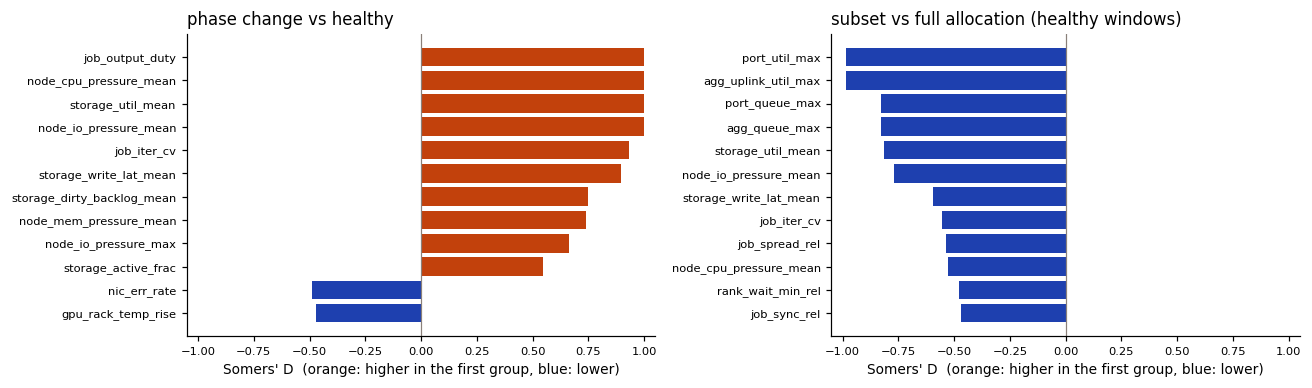

features with |D| > 0.5, subset vs full: 10 of 50


In [14]:
def somers_d(a: pd.DataFrame, b: pd.DataFrame) -> pd.Series:
    both = pd.concat([a, b]); y = np.r_[np.ones(len(a), bool), np.zeros(len(b), bool)]
    out = {}
    for f in both.columns:
        x = both[f].fillna(both[f].median())
        out[f] = 2 * roc_auc_score(y, x) - 1 if x.nunique() > 1 else 0.0
    return pd.Series(out).sort_values(key=abs, ascending=False)
d_phase = somers_d(labelled.loc[labelled["label"] == "phase_change", cols], labelled.loc[labelled["label"] == "healthy", cols])
d_alloc = somers_d(healthy.loc[healthy["alloc"] != "full", cols], healthy.loc[healthy["alloc"] == "full", cols])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, d, title in zip(axes, [d_phase, d_alloc], ["phase change vs healthy", "subset vs full allocation (healthy windows)"]):
    h = d.head(12)[::-1]
    ax.barh(h.index, h.values, color=[A if v > 0 else C for v in h.values]); ax.axvline(0, color=INK3, lw=0.8)
    ax.set_xlim(-1.05, 1.05); ax.set_xlabel("Somers' D  (orange: higher in the first group, blue: lower)")
    ax.set_title(title, loc="left"); ax.tick_params(labelsize=7.5)
plt.tight_layout(); plt.show()
print("features with |D| > 0.5, subset vs full:", int((d_alloc.abs() > 0.5).sum()), "of", len(cols))

## 10. The entity tables

Localisation is a ranking task on two more tables: one row per (window, GPU) and one per (window,
rack), with `positive` marking the injected target. Positives are rare, so the question is whether
the entity-relative features (deviation from the rack or fleet median) push them to the top.

In [15]:
gl = gpu[gpu["label"].isin(mb.CLASSES)]
print("per-GPU rows and positives by window label:")
display(gl.groupby("label")["positive"].agg(rows="size", positives="sum", rate="mean").reindex(mb.CLASSES).round(4))
print("per-rack rows and positives by window label:")
rl = rack[rack["label"].isin(mb.CLASSES)]
display(rl.groupby("label")["positive"].agg(rows="size", positives="sum", rate="mean").reindex(mb.CLASSES).round(3))

per-GPU rows and positives by window label:


,rows,positives,rate
label,,,
healthy,244992,0,0.000
straggler,102144,2388,0.023
network_domain,52704,0,0.000
thermal,62272,17480,0.281
gpu_degradation,51840,576,0.011
phase_change,54528,0,0.000


per-rack rows and positives by window label:


,rows,positives,rate
label,,,
healthy,9657,0,0.000
straggler,4104,0,0.000
network_domain,1990,594,0.298
thermal,2501,690,0.276
gpu_degradation,1933,0,0.000
phase_change,2091,0,0.000


thermal positives at GPU level are every GPU in the hot rack, so the per-GPU signal is the rack median against the fleet,
not the GPU against its own rack; gpu_degradation and straggler positives are single devices.


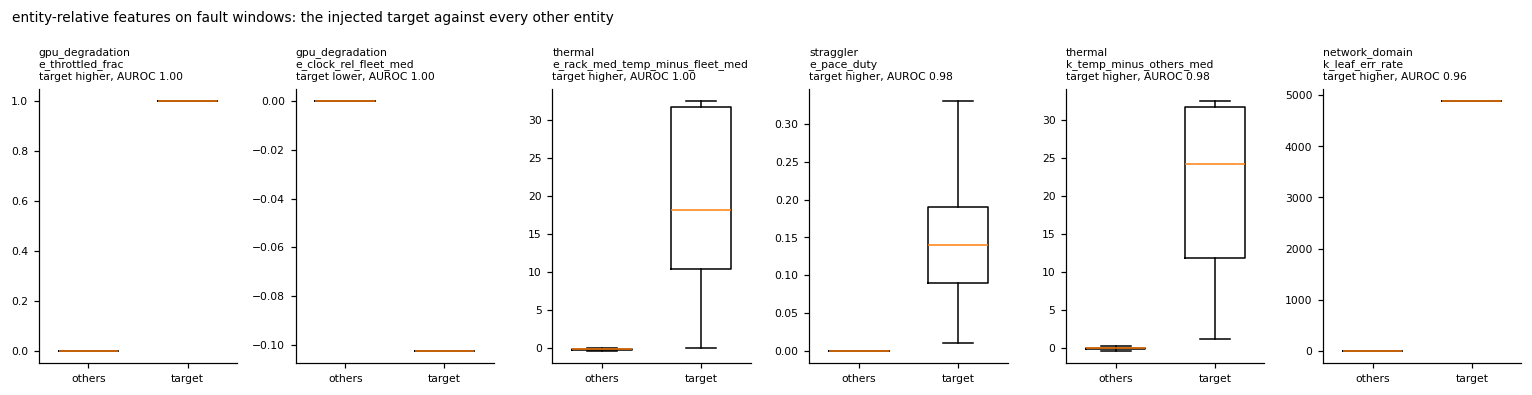

In [16]:
print("thermal positives at GPU level are every GPU in the hot rack, so the per-GPU signal is the rack median against the fleet,")
print("not the GPU against its own rack; gpu_degradation and straggler positives are single devices.")
panels = [("gpu_degradation", gl, "e_throttled_frac"), ("gpu_degradation", gl, "e_clock_rel_fleet_med"),
          ("thermal", gl, "e_rack_med_temp_minus_fleet_med"), ("straggler", gl, "e_pace_duty"),
          ("thermal", rl, "k_temp_minus_others_med"), ("network_domain", rl, "k_leaf_err_rate")]
fig, axes = plt.subplots(1, len(panels), figsize=(14, 3.6))
for ax, (sc, tbl, f) in zip(axes, panels):
    d = tbl[tbl["label"] == sc]
    a, b = d.loc[d["positive"], f].dropna(), d.loc[~d["positive"], f].dropna()
    ax.boxplot([b, a], tick_labels=["others", "target"], showfliers=False, widths=0.6)
    auc = roc_auc_score(d["positive"], d[f].fillna(d[f].median())) if d["positive"].nunique() > 1 else np.nan
    direction = "higher" if auc >= 0.5 else "lower"
    ax.set_title(f"{sc}\n{f}\ntarget {direction}, AUROC {max(auc, 1 - auc):.2f}", fontsize=7, loc="left"); ax.tick_params(labelsize=7)
fig.suptitle("entity-relative features on fault windows: the injected target against every other entity", x=0.01, ha="left", fontsize=9)
plt.tight_layout(); plt.show()

## 11. What the EDA says before any model is trained

- **The matrix is complete and balanced across meshes.** Every scenario × mesh cell has 20 runs
  (10 seeds × 2 allocations) and every run yields the same 91 windows, so no mesh or scenario is
  over-represented by accident. Healthy is the largest class, about 43 % of labelled windows, because
  faulted runs are healthy before their onset; that is by design, and it is why the deck reports
  macro-F1 and false-alarm rate rather than accuracy.
- **Seeds are real augmentation.** Onsets and targets differ from seed to seed in the manifest, and
  the fault share ramps gradually with iteration number instead of stepping, so neither position nor
  identity is a label proxy.
- **Dimensionless is not mesh-invariant.** The excluded columns identify the mesh perfectly, as
  intended, but so do several *model* features: halo-to-compute ratios, occupancy and iteration-time
  variability all take a different healthy value on each mesh because the subdomain's surface-to-volume
  ratio changes. This does not leak the label (every mesh has every class), but it means "healthy" is a
  different point in feature space per mesh, which is exactly why the mesh hold-out is the deck's
  weakest in-distribution result and why the linear model transfers better than the trees.
- **Most classes have a near-perfect univariate signal**, each in the telemetry table the deck
  attributes it to. The supervised model's real job is the two hard pairs: phase change against
  healthy, which turns on the output-duty and node-pressure features, and healthy on a subset
  allocation against healthy on the full cluster, where the fabric and storage utilisation features
  shift wholesale. Section 9 shows both shifts; the second is the allocation hold-out gap.
- **The feature set is redundant.** Dozens of pairs correlate above 0.9, mostly a port-level and an
  aggregation-level view of the same counter. That is harmless for the trees but should be remembered
  when reading permutation importance: shuffling one twin costs little while the other stands in.